# 05 — Extra Trees (Meilleur Modèle)
**Objectif :** Entraîner et évaluer Extra Trees — notre meilleur modèle (R²=0.8286, MAE=3.095).

  EXTRA TREES — VERSION FINALE OPTIMISEE
Dataset charge : 3748 lignes × 9 colonnes
Valeurs manquantes : 0  |  Doublons : 0
Groupes identifies : 59 experiences
Features : 21 numeriques + 3 categorielles = 24 total

Tuning Extra Trees (40 combinaisons)...
R² CV tuning = 0.8194
   n_estimators              = 300
   min_samples_split         = 2
   min_samples_leaf          = 3
   max_features              = 0.8
   max_depth                 = 10

Evaluation 5 folds...
-----------------------------------------------------------------
Fold 1 | R²=0.8941  MAE=2.467  RMSE=3.413
Fold 2 | R²=0.8459  MAE=2.946  RMSE=4.207
Fold 3 | R²=0.8853  MAE=2.451  RMSE=3.415
Fold 4 | R²=0.7893  MAE=3.824  RMSE=5.558
Fold 5 | R²=0.7515  MAE=3.778  RMSE=5.663

  R²   Global : 0.8280
  MAE  Global : 3.0947 vol%
  RMSE Global : 4.5637 vol%
  Std R² folds: 0.0551


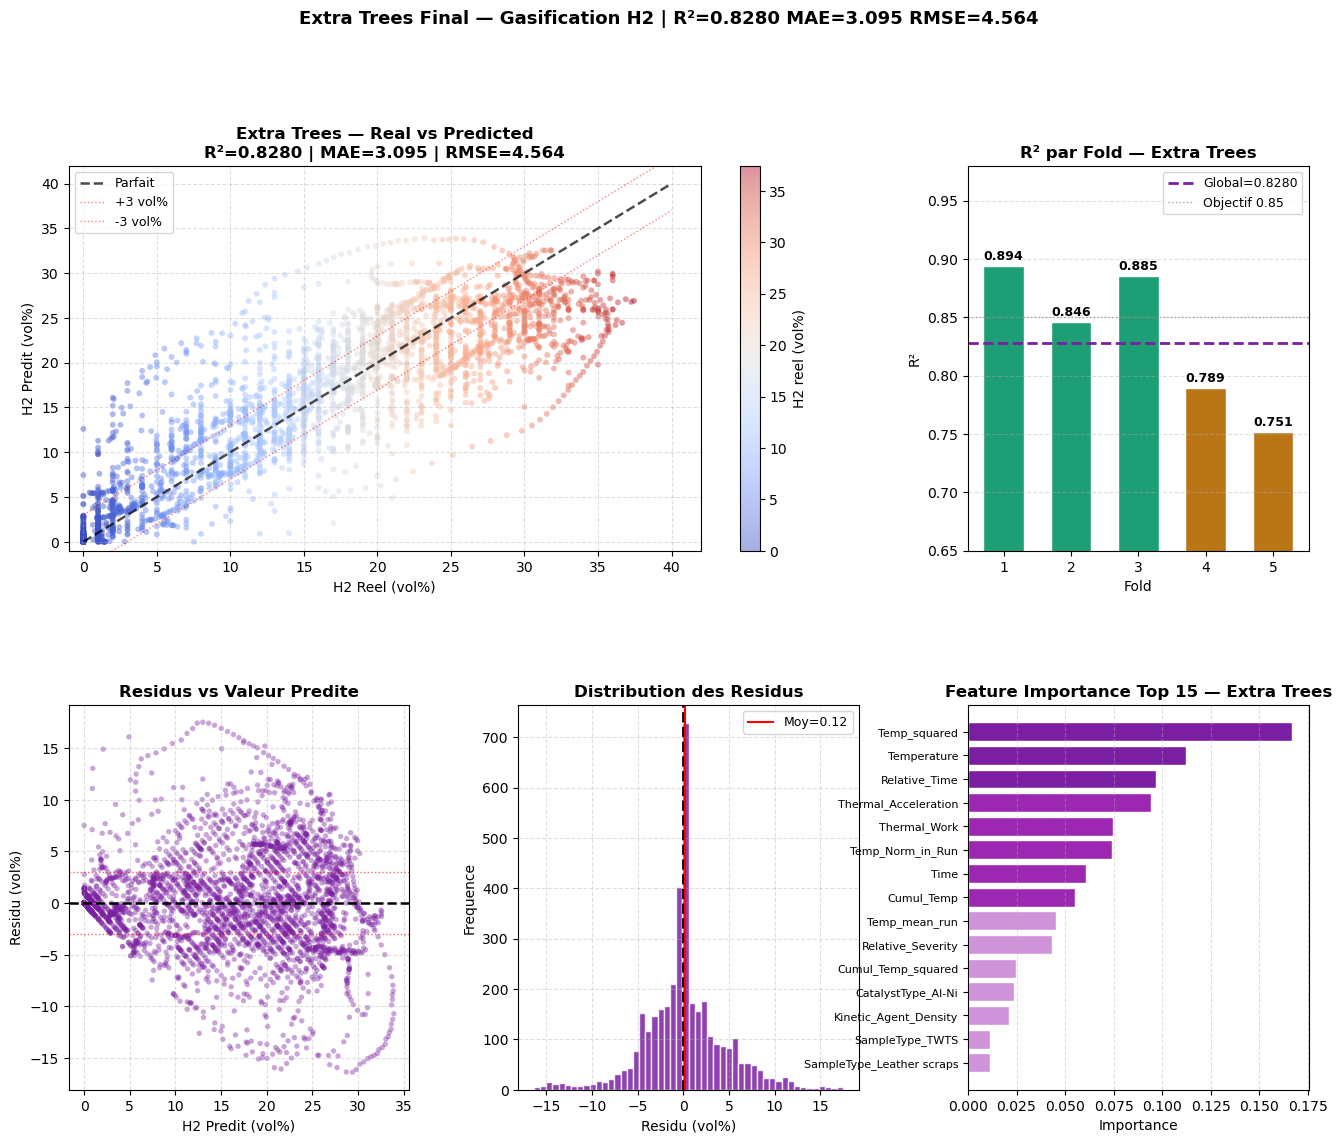


✅ Graphique sauvegarde : ET_final_results.png


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("="*65)
print("  EXTRA TREES — VERSION FINALE OPTIMISEE")
print("="*65)

# ── Chargement & Nettoyage ────────────────────────────────────
import pandas as pd, numpy as np

df = pd.read_csv('Gasification Dataset.csv', delimiter=';')
df.columns = df.columns.str.strip()
for c in df.select_dtypes('object').columns:
    df[c] = df[c].str.strip()
df.loc[df['Hydrogen'] < 0, 'Hydrogen'] = 0.0
print(f"Dataset charge : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"Valeurs manquantes : {df.isnull().sum().sum()}  |  Doublons : {df.duplicated().sum()}")

# ── Experiment_Group + Shuffle ────────────────────────────────
group_cols = ['ProcessTemperature','AgentType','AgentFlow',
              'SampleType','CatalystType','CatalystRatio']
df['Experiment_Group'] = df.groupby(group_cols).ngroup()
df = df.sort_values(['Experiment_Group','Time']).reset_index(drop=True)

rng = np.random.default_rng(42)
shuffled_ids = rng.permutation(df['Experiment_Group'].unique())
remap = {old: new for new, old in enumerate(shuffled_ids)}
df['Experiment_Group'] = df['Experiment_Group'].map(remap)
print(f"Groupes identifies : {df['Experiment_Group'].nunique()} experiences")

# ── Feature Engineering ───────────────────────────────────────
g     = df.groupby('Experiment_Group')
max_t = g['Time'].transform('max')

df['Relative_Time']         = df['Time'] / (max_t + 1e-6)
df['Thermal_Work']          = df['Temperature'] * df['Time']
df['Agent_Intensity']       = df['AgentFlow'] * df['ProcessTemperature']
df['Thermal_Acceleration']  = df['Thermal_Work'] / (df['Time'] + 0.1)
df['Relative_Severity']     = df['Relative_Time'] * df['ProcessTemperature']
df['Kinetic_Agent_Density'] = df['AgentFlow'] * df['Relative_Time']
df['Cumul_Temp']            = g['Temperature'].cumsum()
df['Temp_Norm_in_Run']      = g['Temperature'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-6))
df['Temp_x_AgentFlow']      = df['Temperature'] * df['AgentFlow']
df['Temp_x_CatalystRatio']  = df['Temperature'] * df['CatalystRatio']
df['Cumul_x_AgentFlow']     = df['Cumul_Temp']  * df['AgentFlow']
df['Temp_squared']          = df['Temperature'] ** 2
df['Cumul_Temp_squared']    = df['Cumul_Temp']  ** 2
df['Temp_mean_run']         = g['Temperature'].transform('mean')
df['Temp_max_run']          = g['Temperature'].transform('max')
df['Temp_std_run']          = g['Temperature'].transform('std').fillna(0)

num_cols = [
    'Time','Temperature','ProcessTemperature','AgentFlow','CatalystRatio',
    'Relative_Time','Thermal_Work','Agent_Intensity',
    'Thermal_Acceleration','Relative_Severity','Kinetic_Agent_Density',
    'Cumul_Temp','Temp_Norm_in_Run',
    'Temp_x_AgentFlow','Temp_x_CatalystRatio','Cumul_x_AgentFlow',
    'Temp_squared','Cumul_Temp_squared',
    'Temp_mean_run','Temp_max_run','Temp_std_run',
]
cat_cols = ['AgentType','SampleType','CatalystType']
X      = df[num_cols + cat_cols]
y      = df['Hydrogen']
groups = df['Experiment_Group']
print(f"Features : {len(num_cols)} numeriques + {len(cat_cols)} categorielles = {len(num_cols)+len(cat_cols)} total")

# ── Preprocessing ─────────────────────────────────────────────
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

# ── Tuning Extra Trees ─────────────────────────────────────────
print("\nTuning Extra Trees (40 combinaisons)...")

base_et = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', ExtraTreesRegressor(random_state=42, n_jobs=-1))
])

param_dist_et = {
    'regressor__n_estimators':      [300, 500, 700, 1000],
    'regressor__max_depth':         [10, 15, 20, 25, None],
    'regressor__min_samples_split': [2, 3, 5],
    'regressor__min_samples_leaf':  [1, 2, 3],
    'regressor__max_features':      ['sqrt', 'log2', 0.4, 0.6, 0.8],
}
valid_et = ['n_estimators','max_depth','min_samples_split','min_samples_leaf','max_features']

cv_tuning = GroupKFold(n_splits=3)
search_et = RandomizedSearchCV(base_et, param_distributions=param_dist_et,
    n_iter=40, scoring='r2', cv=cv_tuning, random_state=42, n_jobs=-1, verbose=0)
search_et.fit(X, y, groups=groups)

best_params_et = {k.replace('regressor__',''): v
                  for k,v in search_et.best_params_.items()
                  if k.replace('regressor__','') in valid_et}
print(f"R² CV tuning = {search_et.best_score_:.4f}")
for k,v in best_params_et.items():
    print(f"   {k:25s} = {v}")

# ── Évaluation GroupKFold 5 folds ─────────────────────────────
best_et = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', ExtraTreesRegressor(**best_params_et, random_state=42, n_jobs=-1))
])

gkf = GroupKFold(n_splits=5)
all_y_true, all_y_pred = [], []
fold_scores, fold_maes, fold_rmses = [], [], []

print("\nEvaluation 5 folds..."); print("-"*65)
for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
    sw = np.where(X_tr['SampleType'] == 'TWTS', 2.0, 1.0)
    best_et.fit(X_tr, y_tr, regressor__sample_weight=sw)
    preds = np.clip(best_et.predict(X_te), 0, None)
    all_y_true.extend(y_te.values); all_y_pred.extend(preds)
    f_r2   = r2_score(y_te, preds)
    f_mae  = mean_absolute_error(y_te, preds)
    f_rmse = np.sqrt(mean_squared_error(y_te, preds))
    fold_scores.append(f_r2)
    print(f"Fold {fold+1} | R²={f_r2:.4f}  MAE={f_mae:.3f}  RMSE={f_rmse:.3f}")

global_r2   = r2_score(all_y_true, all_y_pred)
global_mae  = mean_absolute_error(all_y_true, all_y_pred)
global_rmse = np.sqrt(mean_squared_error(all_y_true, all_y_pred))

print(f"\n{'='*65}")
print(f"  R²   Global : {global_r2:.4f}")
print(f"  MAE  Global : {global_mae:.4f} vol%")
print(f"  RMSE Global : {global_rmse:.4f} vol%")
print(f"  Std R² folds: {np.std(fold_scores):.4f}")
print(f"{'='*65}")

# ── Feature importance ──────────────────────────────────────────
best_et.fit(X, y)
et_fitted = best_et.named_steps['regressor']
ohe_cols  = best_et.named_steps['preprocessor']\
                    .named_transformers_['cat']\
                    .get_feature_names_out(cat_cols).tolist()
all_feat  = num_cols + ohe_cols
importances = pd.Series(et_fitted.feature_importances_, index=all_feat)\
                .sort_values(ascending=False)

# ── Visualisations ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.32)
all_true = np.array(all_y_true); all_pred = np.array(all_y_pred)

ax1 = fig.add_subplot(gs[0, 0:2])
sc  = ax1.scatter(all_true, all_pred, alpha=0.45, s=18,
                  c=all_true, cmap='coolwarm', edgecolor='none')
ax1.plot([0,40],[0,40],'k--',lw=1.8,alpha=0.7,label='Parfait')
ax1.plot([0,40],[3,43],'r:',lw=1,alpha=0.5,label='+3 vol%')
ax1.plot([0,40],[-3,37],'r:',lw=1,alpha=0.5,label='-3 vol%')
plt.colorbar(sc, ax=ax1, label='H2 reel (vol%)')
ax1.set_title(f"Extra Trees — Real vs Predicted\nR²={global_r2:.4f} | MAE={global_mae:.3f} | RMSE={global_rmse:.3f}",
              fontsize=12, fontweight='bold')
ax1.set_xlabel("H2 Reel (vol%)"); ax1.set_ylabel("H2 Predit (vol%)")
ax1.set_xlim(-1,42); ax1.set_ylim(-1,42)
ax1.legend(fontsize=9); ax1.grid(True,linestyle='--',alpha=0.4)

ax2 = fig.add_subplot(gs[0, 2])
fold_colors = ['#1D9E75' if r>=0.82 else '#BA7517' if r>=0.75 else '#E24B4A' for r in fold_scores]
bars = ax2.bar(range(1,6), fold_scores, color=fold_colors, edgecolor='white', width=0.6)
ax2.axhline(global_r2, color='#7B1FA2', lw=2, ls='--', label=f'Global={global_r2:.4f}')
ax2.axhline(0.85, color='gray', lw=1, ls=':', alpha=0.7, label='Objectif 0.85')
for bar,val in zip(bars,fold_scores):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_ylim(0.65,0.98); ax2.set_title("R² par Fold — Extra Trees", fontsize=12, fontweight='bold')
ax2.set_xlabel("Fold"); ax2.set_ylabel("R²"); ax2.set_xticks(range(1,6))
ax2.legend(fontsize=9); ax2.grid(True,axis='y',linestyle='--',alpha=0.4)

ax3 = fig.add_subplot(gs[1, 0])
residuals = all_true - all_pred
ax3.scatter(all_pred, residuals, alpha=0.4, s=15, color='#7B1FA2', edgecolor='none')
ax3.axhline(0, color='black', lw=1.8, ls='--')
ax3.axhline(3, color='red', lw=1, ls=':', alpha=0.6)
ax3.axhline(-3, color='red', lw=1, ls=':', alpha=0.6)
ax3.set_title("Residus vs Valeur Predite", fontsize=12, fontweight='bold')
ax3.set_xlabel("H2 Predit (vol%)"); ax3.set_ylabel("Residu (vol%)")
ax3.grid(True, linestyle='--', alpha=0.4)

ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(residuals, bins=50, color='#7B1FA2', edgecolor='white', alpha=0.85)
ax4.axvline(0, color='black', lw=2, ls='--')
ax4.axvline(residuals.mean(), color='red', lw=1.5, label=f'Moy={residuals.mean():.2f}')
ax4.set_title("Distribution des Residus", fontsize=12, fontweight='bold')
ax4.set_xlabel("Residu (vol%)"); ax4.set_ylabel("Frequence")
ax4.legend(fontsize=9); ax4.grid(True, linestyle='--', alpha=0.4)

ax5 = fig.add_subplot(gs[1, 2])
top15 = importances.head(15)
colors_fi = ['#7B1FA2' if i<3 else '#9C27B0' if i<8 else '#CE93D8' for i in range(len(top15))]
ax5.barh(range(len(top15)), top15.values[::-1], color=colors_fi[::-1], edgecolor='white')
ax5.set_yticks(range(len(top15))); ax5.set_yticklabels(top15.index[::-1], fontsize=8)
ax5.set_title("Feature Importance Top 15 — Extra Trees", fontsize=12, fontweight='bold')
ax5.set_xlabel("Importance"); ax5.grid(True, axis='x', linestyle='--', alpha=0.4)

fig.suptitle(f"Extra Trees Final — Gasification H2 | R²={global_r2:.4f} MAE={global_mae:.3f} RMSE={global_rmse:.3f}",
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('ET_final_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Graphique sauvegarde : ET_final_results.png")

In [2]:
# ── Sauvegarder le modèle Extra Trees ──────────────────────────
import joblib, os
os.makedirs('models', exist_ok=True)
best_et.fit(X, y)
joblib.dump(best_et, 'models/model_extra_trees.pkl')
print("✅ Modèle Extra Trees sauvegardé : models/model_extra_trees.pkl")
print(f"   R² global : {global_r2:.4f}  |  MAE : {global_mae:.4f}  |  RMSE : {global_rmse:.4f}")

✅ Modèle Extra Trees sauvegardé : models/model_extra_trees.pkl
   R² global : 0.8280  |  MAE : 3.0947  |  RMSE : 4.5637
